# Khám phá và trực quan hóa dữ liệu QOS Maintenance

Notebook đọc ba biến số cần phân tích, kiểm tra chất lượng dữ liệu, tính tương quan Pearson/Spearman và vẽ một số biểu đồ cơ bản.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
sns.set_theme(style="whitegrid")

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "QOS_MAINTENANCE_utf8.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy file: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng × {df.shape[1]} cột")
df.head()

Kích thước dữ liệu: 502,210 dòng × 19 cột


,OBJ_ID,BRANCH_NAME,CHECKLIST_ID,CHECKLIST_STATUS,CREATE_DATE,FINISH_DATE,CASE_TYPE,SERVICES_LIST,OBJ_LOCATION,OBJ_TYPE_LV1,OBJ_TYPE_VIP,FLAG_ON_TIME,NUM_DISCUSSION,NUM_SOS_DISCUSSION,NUM_APPOINTMENT,EMP_ACCOUNT,EMP_LEVEL,APPOINTTIMES_ASSIGNED,PROCESS_NOTE
0,5188995,VPC,1484564116,Đã xử lý,6/29/2026 2:44 PM,6/30/2026 10:08 AM,MAINTENANCE,Internet,"92 Pho Nha Chung (Yen Mi 1), Phuong Xuan Hoa, Phu Tho",Cá nhân,0,YES,0,0,1,VPCTI.TAIND4,1.0,1,"VPAAA8359 - 0984915990 - ĐINH VĂN TIẾN: Lỗi Internet- Không có internet, no ipw, Enable/ Offline/ LOSi. SOC tạo CLBT tích hẹn xanh gần nhất. Nhờ KT qua htro a. chat OB ok \n>> VPCTI.TAIND4 30/06/2026 09:05:24: lỗi fc tại tập điểm kt đã qua thay thế kh sdug lại btg"
1,1135441,HNI_02,1480041636,Đóng checklist,6/1/2026 10:40 AM,-1,MAINTENANCE,Internet,"So nha 31 ngo 1 Tan Khai, Phuong Vinh Tuy, Ha Noi",Cá nhân,0,NaN,0,0,1,TIN0202.KHANHDH1,1.0,1,hieunt54 01/06/2026 19:25:50:(đóng phiếu)
2,2030265,BGG,1480065036,Đã xử lý,6/1/2026 1:43 PM,6/1/2026 5:42 PM,MAINTENANCE,Internet,"ac Manh Hanh xom 3 Thon Mi Dien 1, Phuong Nenh, Bac Giang",Cá nhân,0,YES,0,0,1,BGGTI.KIENND1,1.0,1,NaN
3,684976,DNG_01,1480152566,Đã xử lý,6/2/2026 8:28 AM,6/2/2026 9:04 AM,MAINTENANCE,Internet,"K245/H2/11 Au Co, Phuong Lien Chieu, Da Nang",Cá nhân,0,YES,0,0,1,DNG01.NGHIAND,4.0,1,"\n>> DNG01.NGHIAND 02/06/2026 09:03:43: B1-Liên hệ KHG0394010294\nB2-Tình trạng lỗi:ko co ip\nMô hình nhà KH:cấp 4, \nMô hình thiết bị:ONT+3000CV2, 2 cam imou, 4dt\nB3-Kiểm tra lỗi:modem treo\nB4-Phương án xử lý:kt kiểm tra modem bị treo do treo.kt úp lại ffw mới cho modem check lại dich vụ cho kh ok\nB5-Hướng dẫn sử dụng:kh dùng lại bt\nB6-Khuyến cáo: tắt mo định kì thiết bị \nB7-Nghiệm thu:băng thông, vùng phủ sóng đảm bảo \nB8-Trường lỗi/Ngày recare:2/6\nB9-kh biết thanh toán cước online"
4,5650073,HCM_08,1480313796,Đã xử lý,6/3/2026 9:53 AM,6/3/2026 10:41 AM,MAINTENANCE,Internet,"8/3/3 Duong TTH 06, P.Tan Thoi Hiep, Phuong Tan Thoi Hiep, HCM",Cá nhân,0,YES,0,0,1,PNC08.HIENL,1.0,1,"\n>> PNC08.HIENL 03/06/2026 10:41:30: 1. Tổng CL trong 6T: 0\n2. Liên hệ KH: 0703379448\n3.Mô hình nhà diện tích: nha trong hem 87 chay toi nga 3 queo trai, toi nga 3 nho queo trai tiep, can dau ben trai cuoi hem\n4. Mô hình thiết bị: 3000cv2\n5.Số lượng thiết bị kết nối: 6\n6. Nguyên nhân lỗi: fc bi suy hao\n7. Phương án xử lý: kt da bam lai fc cho kh du cs ok, cau hinh doi ten mk wf theo yc cua kh ok, check wf tivi cho kh sd ok.\n8. Kết quả Mỹ Bảo: đã check OK\n9. KH cần trang bị thêm MD/AP/thiết bị khác:\n10.Kết quả tư vấn V.VIP: \n11. KTV tham khảo DT lắp thêm AP:ko"


## 1. Kiểm tra dữ liệu cơ bản

In [6]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(),
    "zero_%": (df.eq(0).mean() * 100).round(2),
})
summary

,dtype,missing,missing_%,unique,zero_%
OBJ_ID,int64,0,0.00,435237,0.00
BRANCH_NAME,str,0,0.00,135,0.00
CHECKLIST_ID,int64,0,0.00,477773,0.00
CHECKLIST_STATUS,str,0,0.00,8,0.00
CREATE_DATE,str,0,0.00,35456,0.00
FINISH_DATE,str,0,0.00,31337,0.00
CASE_TYPE,str,0,0.00,1,0.00
SERVICES_LIST,str,1352,0.27,20,0.00
OBJ_LOCATION,str,108,0.02,424849,0.00
OBJ_TYPE_LV1,str,143,0.03,3,0.00


In [7]:
df.describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).T

,count,mean,std,min,50%,75%,90%,95%,99%,max
OBJ_ID,502210.0,2.199908e+07,2.670699e+07,8.900000e+01,6.202960e+06,4.651376e+07,6.718533e+07,7.467235e+07,8.636267e+07,8.823037e+07
CHECKLIST_ID,502210.0,1.482386e+09,1.378119e+06,1.479980e+09,1.482387e+09,1.483577e+09,1.484296e+09,1.484536e+09,1.484727e+09,1.484776e+09
OBJ_TYPE_VIP,502210.0,1.673866e+00,2.365137e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,3.520000e+02
NUM_DISCUSSION,502210.0,2.275920e-01,7.964199e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,4.900000e+01
NUM_SOS_DISCUSSION,502210.0,7.771649e-03,1.858835e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.400000e+01
NUM_APPOINTMENT,502210.0,1.177466e+00,6.010695e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,1.600000e+01
EMP_LEVEL,502210.0,1.825555e+00,1.626736e+00,0.000000e+00,1.000000e+00,2.000000e+00,5.000000e+00,5.000000e+00,6.000000e+00,7.000000e+00
APPOINTTIMES_ASSIGNED,502210.0,9.826348e-01,3.329884e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.200000e+01


## 2. Ma trận tương quan

- Pearson đo mức độ liên hệ tuyến tính và nhạy với ngoại lệ.
- Spearman dựa trên thứ hạng, phù hợp để kiểm tra quan hệ đơn điệu khi dữ liệu lệch.

In [8]:
COLS = ['NUM_DISCUSSION', 'NUM_SOS_DISCUSSION', 'NUM_APPOINTMENT']
num_flag = df[COLS]
pearson_corr = num_flag.corr(method="pearson")
spearman_corr = num_flag.corr(method="spearman")

print("Pearson:")
display(pearson_corr.round(3))
print("Spearman:")
display(spearman_corr.round(3))

Pearson:


,NUM_DISCUSSION,NUM_SOS_DISCUSSION,NUM_APPOINTMENT
NUM_DISCUSSION,1.000,0.493,0.060
NUM_SOS_DISCUSSION,0.493,1.000,0.026
NUM_APPOINTMENT,0.060,0.026,1.000


Spearman:


,NUM_DISCUSSION,NUM_SOS_DISCUSSION,NUM_APPOINTMENT
NUM_DISCUSSION,1.000,0.178,0.060
NUM_SOS_DISCUSSION,0.178,1.000,0.025
NUM_APPOINTMENT,0.060,0.025,1.000


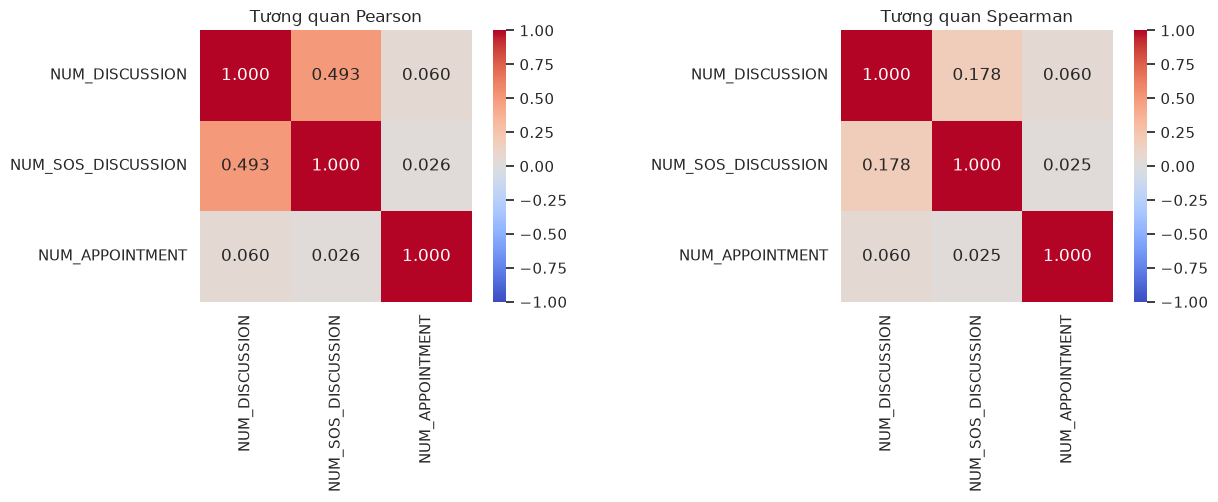

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    pearson_corr, annot=True, fmt=".3f", cmap="coolwarm",
    vmin=-1, vmax=1, square=True, ax=axes[0]
)
axes[0].set_title("Tương quan Pearson")

sns.heatmap(
    spearman_corr, annot=True, fmt=".3f", cmap="coolwarm",
    vmin=-1, vmax=1, square=True, ax=axes[1]
)
axes[1].set_title("Tương quan Spearman")

plt.tight_layout()
plt.show()

## 3. Phân phối giá trị

Dùng thang log ở trục tung vì dữ liệu có nhiều giá trị 0 và một số giá trị hiếm.

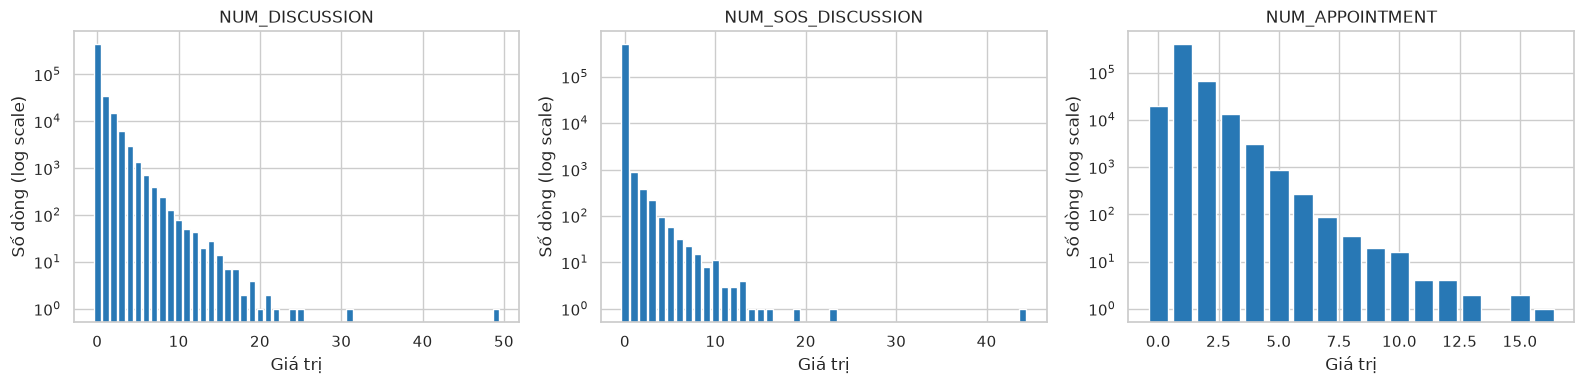

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for col, ax in zip(COLS, axes):
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="#2878B5")
    ax.set_yscale("log")
    ax.set_title(col)
    ax.set_xlabel("Giá trị")
    ax.set_ylabel("Số dòng (log scale)")

plt.tight_layout()
plt.show()

## 5. Xem các dòng có giá trị cao bất thường

In [11]:
df.sort_values(COLS, ascending=False).head(20)

,OBJ_ID,BRANCH_NAME,CHECKLIST_ID,CHECKLIST_STATUS,CREATE_DATE,FINISH_DATE,CASE_TYPE,SERVICES_LIST,OBJ_LOCATION,OBJ_TYPE_LV1,OBJ_TYPE_VIP,FLAG_ON_TIME,NUM_DISCUSSION,NUM_SOS_DISCUSSION,NUM_APPOINTMENT,EMP_ACCOUNT,EMP_LEVEL,APPOINTTIMES_ASSIGNED,PROCESS_NOTE
23870,17555907,TNH,1480214486,Đã xử lý,6/2/2026 2:33 PM,6/4/2026 10:01 AM,MAINTENANCE,Internet,"087 Tran Van Tra, Xa Tan Hoi, Tay Ninh",Cá nhân,0,NO,49,44,1,TNHPN.NHANHLM,1.0,1,"\n>> TNHPN.NHANHLM 03/06/2026 17:53:04: kh suy hao cao, trời mưa kt ko kéo lại đc, hẹn kh sáng mai kh ok.\n>> TNHPN.NHANHLM 04/06/2026 10:01:16: kt đã kéo lại toàn tuyến do câp suy hao, lh SD bth."
421905,14391169,SLA,1483877616,Đóng checklist,6/25/2026 7:23 AM,-1,MAINTENANCE,Internet,"Nha Do Sinh Ban Tong, Phuong Chieng An, Son La",Cá nhân,0,NaN,31,23,8,SLATI.DUCTV1,4.0,1,"\n>> linhln6.tin 25/06/2026 11:20:45: SLAAB1917 - 0943124345 - ĐỖ THỊ SINH: Kh giục tiến độ bảo trì, Kh báo mạng chập chờn. chậm rớt kết nối liên tục, ktra ONU:-32.22 … suy hao k đạt chuẩn, kh nhờ KT qua bảo trì giúp sớm , lh SLTo TIN (300) ( SLATI.DUCTV1 ) - 0981396667 nhờ KT care giúp gọi lại kh nắm thông tin tgian qua bảo trì, đã tạo TK giục\n>> SLATI.DUCTV1 25/06/2026 11:24:43: đã qua nhà trao đổi với bố mẹ rồi từ giờ bố mẹ gọi tổng đài thì mới sửa còn báo qua hi fpt không phải bố mẹ gọi không sữa không ai đi hầu mãi đk, con bị bệnh thần kinh đk 2 3 ngày tự tháo fc ra tự báo hỏng, qua tận nhà ỷao đổi QA CHI NHÁNH cũng qua rồi hết trả trước thu tb từ chối không hỗ trợ, cả 3 nhà mạng đều từ chốihieunh7 26/06/2026 15:18:53:(đóng phiếu)"
368528,17237705,VPC,1483509056,Đã xử lý,6/22/2026 6:47 PM,6/24/2026 7:41 PM,MAINTENANCE,Internet,"so 10 Thon Thanh Tri, Soc Son, Phu Tho",Cá nhân,0,YES,25,14,2,VPCTI.HAITV9,1.0,1,"VPAAE2121 - 0983715316 - Số ĐT chính chủ:kh báo đường truyền mất tín hiệu, ko ipw, đèn báo đỏ , tắt mở md nok, YC hỗ trợ sớm NL đỏ, mkn 2 ngày nay,nhờ kt care giúp\n>> phuongnam.NhaTPT1 23/06/2026 20:00:51: VPAAE2121 - 0983715316 - Số ĐT chính chủ:kh có CL hẹn Lần 2:Hẹn đỏ:22 giờ - 15:30 - 17:30 24/06/2026 - VPCTI.HAITV9 kh giục nói chưa có net sd chưa có kt htro đã xin lỗi thuyết phục kh chờ KT htro trong ngày 24/6 kh ok đồng ý chờ,kh ycau htro sớm trong ngày 24/3 để có net sd lh 0983715316 nhờ kt htro giúp em.\n>> VPCTI.HAITV9 24/06/2026 11:34:28: 0983715316 điện lực thay cột làm đut dây KT đa kéo lại dây rep lại cho kh SD ok"
25334,84437364,TNN,1480212876,Đã xử lý,6/2/2026 2:14 PM,6/8/2026 9:15 AM,MAINTENANCE,Internet,"Ke ben phai Xom Cau Thong Duong 261, Xa Dai Tu, Thai Nguyen",Cá nhân,0,NO,24,19,1,TNNTI.THINHND8,1.0,1,TNAAH8156 - 0333580851 - Phạm Văn Tiềm:Kh báo Không truy cập được mạng Nhờ KT nắm thông tin qua kiểm tra AutoSystem 02/06/2026 15:00:17: Cập nhật nguồn tạo chuyển ES TIN/PNC (73)\n>> TNNTI.KHOINH1 05/06/2026 16:32:22: 0333580851. khu vực nhà khách làm đường chỗ tạp điểm.cột điện đã nhổ đi.hướng thi công ko đảm bảo an toàn.ko có cột neo trụ cáp.đã đến nhà khách và giải thích.khách báo cần hỗ trợ sớm.\n>> TNNTI.THINHND8 08/06/2026 09:14:56: kỹ thuật đã hỗ trợ khách kéo lại toàn tuyến do khách chuyển cột làm đường.khách sử dụng ok
426104,5718334,LAN,1484115206,Đã xử lý,6/26/2026 1:51 PM,7/2/2026 10:38 AM,MAINTENANCE,Internet,"139E to 1 Ap 5 ((10.8270670, 106.4771650)), Xa My Hanh, Tay Ninh",Cá nhân,0,NO,22,13,3,LANPN.HOPTK,0.0,1,"LAAAB9389 - 0356638227 - Số ĐT chính chủ:Kh báo đường dây thuê bao của kh bị đứt cáp bên ngoài, ktra tình trạng dis-off, ko ipwan , nhờ KT htro giúp. \n>> LANPN.HOPTK 26/06/2026 17:10:32: dân đang trồng trụ, đợi trồng xong mới bảo trì được\n>> LANPN.HOPTK 02/07/2026 10:32:14: đứt cáp, nối rệp trụ thứ 2 từ nhà kh đến tập điểm"
178628,72453509,HNI_07,1481621346,Đóng checklist,6/11/2026 10:48 AM,-1,MAINTENANCE,Internet,"181 c10 khu 98 Phuc Dong, Phuong Phuc Loi, Ha Noi",Cá nhân,0,NaN,21,16,1,TIN0701.THANGLM4,1.0,1,\n>> TIN0701.THANGLM4 11/06/2026 11:24:25: 0387415983.kh báo hủy.cus yêu cầu kt qua thu thiết biutiendq.tin 11/06/2026 16:30:46:DVKH tao len de onsite thu thiết bi(

In [12]:
import pandas as pd

date_cols = ["CREATE_DATE", "FINISH_DATE"]

for col in date_cols:
    df[col] = (
        df[col]
        .replace("-1", pd.NA)
        .pipe(
            pd.to_datetime,
            format="mixed",
            errors="coerce"
        )
    )

print(df[date_cols].dtypes)
display(df[date_cols].head(10))

df["PROCESS_HOURS"] = (
    df["FINISH_DATE"] - df["CREATE_DATE"]
)

display(
    df[
        ["CREATE_DATE", "FINISH_DATE", "PROCESS_HOURS"]
    ].head(20)
)

CREATE_DATE    datetime64[us]
FINISH_DATE    datetime64[us]
dtype: object


,CREATE_DATE,FINISH_DATE
0,2026-06-29 14:44:00,2026-06-30 10:08:00
1,2026-06-01 10:40:00,NaT
2,2026-06-01 13:43:00,2026-06-01 17:42:00
3,2026-06-02 08:28:00,2026-06-02 09:04:00
4,2026-06-03 09:53:00,2026-06-03 10:41:00
5,2026-06-04 14:38:00,2026-06-05 16:12:00
6,2026-06-04 13:52:00,2026-06-05 11:33:00
7,2026-06-05 19:55:00,NaT
8,2026-06-05 08:42:00,2026-06-05 09:10:00
9,2026-06-06 11:20:00,2026-06-07 08:46:00


,CREATE_DATE,FINISH_DATE,PROCESS_HOURS
0,2026-06-29 14:44:00,2026-06-30 10:08:00,0 days 19:24:00
1,2026-06-01 10:40:00,NaT,NaT
2,2026-06-01 13:43:00,2026-06-01 17:42:00,0 days 03:59:00
3,2026-06-02 08:28:00,2026-06-02 09:04:00,0 days 00:36:00
4,2026-06-03 09:53:00,2026-06-03 10:41:00,0 days 00:48:00
5,2026-06-04 14:38:00,2026-06-05 16:12:00,1 days 01:34:00
6,2026-06-04 13:52:00,2026-06-05 11:33:00,0 days 21:41:00
7,2026-06-05 19:55:00,NaT,NaT
8,2026-06-05 08:42:00,2026-06-05 09:10:00,0 days 00:28:00
9,2026-06-06 11:20:00,2026-06-07 08:46:00,0 days 21:26:00


In [ ]:
unfinished = df[df["FINISH_DATE"].isna()]

print(f"Số dòng FINISH_DATE là NaT: {len(unfinished):,}")

print("\nCHECKLIST_STATUS:")
display(
    unfinished["CHECKLIST_STATUS"]
    .value_counts(dropna=False)
    .to_frame("COUNT")
)

print("\nFLAG_ON_TIME:")
display(
    unfinished["FLAG_ON_TIME"]
    .value_counts(dropna=False)
    .to_frame("COUNT")
)



Số dòng FINISH_DATE là NaT: 43,538

CHECKLIST_STATUS:


,COUNT
CHECKLIST_STATUS,
Đóng checklist,43500
Đang xử lý,15
Đã xử lý và đang theo dõi,8
Chưa phân công,7
Tạm dừng chờ xử lý,5
Đã phân công,3



FLAG_ON_TIME:


,COUNT
FLAG_ON_TIME,
NaN,43500
INPROCESS,38


In [18]:
unassigned = df[
    df["CHECKLIST_STATUS"] == "Đã phân công"
]

print(f"Số checklist chưa phân công: {len(unassigned):,}")
display(unassigned)

Số checklist chưa phân công: 3


,OBJ_ID,BRANCH_NAME,CHECKLIST_ID,CHECKLIST_STATUS,CREATE_DATE,FINISH_DATE,CASE_TYPE,SERVICES_LIST,OBJ_LOCATION,OBJ_TYPE_LV1,OBJ_TYPE_VIP,FLAG_ON_TIME,NUM_DISCUSSION,NUM_SOS_DISCUSSION,NUM_APPOINTMENT,EMP_ACCOUNT,EMP_LEVEL,APPOINTTIMES_ASSIGNED,PROCESS_NOTE,PROCESS_HOURS
192804,56816205,LAN,1481839496,Đã phân công,2026-06-12 16:29:00,NaT,MAINTENANCE,Internet,"0776149097 Ap Cau Tram, Xa Rach Kien, Tay Ninh",Cá nhân,0,INPROCESS,0,0,1,LANPN.GIANGVT1,5.0,1,Thinhpt15 15/06/2026 15:35:57: Cập nhật nguồn tạo chuyển ES TIN/PNC (10)Thinhpt15 16/06/2026 18:00:51: Cập nhật nguồn tạo chuyển ES TIN/PNC (10)\n>> LANPN.GIANGVT1 18/06/2026 12:42:38: lh kh bao ko có báo bảo trì do ma su co he thong tu nhay phieu bao triThinhpt15 18/06/2026 17:01:10: Cập nhật nguồn tạo chuyển ES TIN/PNC (10)\n>> Phuongnam.thaocha 21/07/2026 10:07:26: kh trả mặt bằng . chưa thuê lại mat bang khác . khi nào co mat bang mơi sẽ su dụng . chuyển thông tin dvkh năm thông tin\n>> Phuongnam.thaocha 21/07/2026 10:07:43: kh k có nhu câu bt -,NaT
380519,74332132,HCM_01,1483632816,Đã phân công,2026-06-23 14:34:00,NaT,MAINTENANCE,IT service,"39 Xuan Thuy, Phuong An Khanh, Ho Chi Minh",Tổ chức/Hộ kinh doanh,0,INPROCESS,0,0,0,SFPRO.PHUBQ2,1.0,0,\n>> phubq2 23/06/2026 14:34:34: [Chuyển đối tác: Fpro ],NaT
478901,53412388,HTH,1484520256,Đã phân công,2026-06-29 10:23:00,NaT,MAINTENANCE,Internet,"Nha Thang Oanh Xom Phu Xuan, Xa Loc Ha, Ha Tinh",Cá nhân,0,INPROCESS,2,0,2,HTHTI.TIENTN4,1.0,2,AutoSystem 30/06/2026 08:52:47: Cập nhật nguồn tạo chuyển ES TIN/PNC (62)\n>> HTHTI.THUONGQH 30/06/2026 10:18:19: kv evn đang chỉnh trang làm gọn bó cápAutoSystem 30/06/2026 12:01:47: Cập nhật nguồn tạo chuyển ES TIN/PNC (10)\n>> HTHTI.TIENTN4 06/07/2026 18:27:56: dl chinh trang,NaT


In [14]:
filtered = df[
    (df["NUM_DISCUSSION"] == df["NUM_SOS_DISCUSSION"])
    & (df["NUM_SOS_DISCUSSION"] > 0)
]
print(filtered.head())

         OBJ_ID BRANCH_NAME  CHECKLIST_ID CHECKLIST_STATUS  \
2212    7493663         NBH    1481935186         Đã xử lý   
13970   3477411         LDG    1480049776         Đã xử lý   
15476  13644489         THA    1480039986         Đã xử lý   
30143   3596173      HCM_08    1480218076         Đã xử lý   
30748   1917052      HNI_07    1480232886         Đã xử lý   

              CREATE_DATE         FINISH_DATE    CASE_TYPE SERVICES_LIST  \
2212  2026-06-13 09:08:00 2026-06-13 21:31:00  MAINTENANCE      FPT Play   
13970 2026-06-01 12:02:00 2026-06-01 17:04:00  MAINTENANCE      Internet   
15476 2026-06-01 11:36:00 2026-06-02 07:55:00  MAINTENANCE      Internet   
30143 2026-06-02 15:20:00 2026-06-03 15:15:00  MAINTENANCE      Internet   
30748 2026-06-02 16:04:00 2026-06-09 10:49:00  MAINTENANCE      Internet   

                                                                                   OBJ_LOCATION  \
2212   anh hao lam da Binh Yen Tay (Nha mau xanh duong), P.Ninh Khanh, 

In [15]:
import pandas as pd

checkin = pd.read_csv(
    "data/QOS_MAINT_CHECKIN_INFO_utf8.csv",
    dtype={
        "CHECKLIST_ID": "string",
        "EMP_CODE": "string",
    }
)

na_summary = pd.DataFrame({
    "NA_COUNT": checkin.isna().sum(),
    "NA_PERCENT": (checkin.isna().mean() * 100).round(2),
})

display(na_summary)

FileNotFoundError: [Errno 2] No such file or directory: 'data/QOS_MAINT_CHECKIN_INFO_utf8.csv'

In [ ]:
rows_with_na = checkin[
    checkin.isna().any(axis=1)
]
maintenance = pd.read_csv(
    "data/QOS_MAINTENANCE_utf8.csv",
    dtype={
        "CHECKLIST_ID": "string",
        "EMP_CODE": "string",
    }
)

print(f"Số dòng có NA: {len(rows_with_na):,}")
display(rows_with_na.head(50))
# Nối các dòng có NaN bên checkin với thông tin bên maintenance
linked_na = rows_with_na.merge(
    maintenance,
    on="CHECKLIST_ID",
    how="left",
    suffixes=("_CHECKIN", "_MAINTENANCE")
)

print(f"Số dòng sau khi nối: {len(linked_na):,}")
display(linked_na.head(50))

Số dòng có NA: 216,547


,CHECKLIST_ID,LAT_LNG_IN,LAT_LNG_OUT,CHECKIN_DATE,CHECKOUT_DATE,EMP_CODE
2,1479980486,"(10.7738502,106.6828359)",NaN,6/1/2026 11:34 AM,-1,00302258
3,1479980496,"(20.946470551335242,105.75446596257352)",NaN,6/1/2026 3:21 PM,-1,00141213
7,1479980516,"(10.986436281486345,106.65258987776792)",NaN,6/1/2026 5:16 PM,-1,00373378
8,1479980526,"(21.2727967,105.65179)",NaN,6/1/2026 11:24 AM,-1,00352365
13,1479980576,"(20.94676,105.8484117)",NaN,6/1/2026 9:23 AM,-1,00264503
14,1479980586,"(21.0007828,105.7981635)",NaN,6/1/2026 7:51 AM,-1,00134002
15,1479980596,"(21.0622633,105.8970867)",NaN,6/1/2026 8:22 AM,-1,00210688
17,1479980606,"(20.8508733,106.6668533)",NaN,6/1/2026 11:28 AM,-1,00053525
20,1479980636,NaN,NaN,NaN,NaN,<NA>
21,1479980646,"(19.0053019,105.5024918)",NaN,6/1/2026 6:02 PM,-1,00370455


Số dòng sau khi nối: 224,439


,CHECKLIST_ID,LAT_LNG_IN,LAT_LNG_OUT,CHECKIN_DATE,CHECKOUT_DATE,EMP_CODE,OBJ_ID,BRANCH_NAME,CHECKLIST_STATUS,CREATE_DATE,FINISH_DATE,CASE_TYPE,SERVICES_LIST,OBJ_LOCATION,OBJ_TYPE_LV1,OBJ_TYPE_VIP,FLAG_ON_TIME,NUM_DISCUSSION,NUM_SOS_DISCUSSION,NUM_APPOINTMENT,EMP_ACCOUNT,EMP_LEVEL,APPOINTTIMES_ASSIGNED,PROCESS_NOTE
0,1479980486,"(10.7738502,106.6828359)",NaN,6/1/2026 11:34 AM,-1,00302258,6697883,HCM_04,Đã xử lý,6/1/2026,6/2/2026 10:03 AM,MAINTENANCE,FPT Camera Combo,"6/6 Vuon Chuoi, Phuong Ban Co, Ho Chi Minh",Cá nhân,0,YES,0,0,2,PNC04.CHUONGAP,6.0,2,"\n>> PNC04.MANHND2 01/06/2026 11:36:27: kt qua nhà kh, kh hẹn sáng mai trước 10h\n>> PNC04.CHUONGAP 02/06/2026 10:03:15: CHUONGAP_note\r\n- Số CLs trong năm: \r 1\n- Liên hệ KH: \r 0797520032\n- Mô hình nhà: \r 1 trệt 1 lầu\n- Mô hình thiết bị: \r \n- Tổng thiết bị sử dụng: \r\n- Nguyên nhân lỗi: \r KH đổi pass wifi\n- Phương án xử lý: kết nối lại\n- TOOL Mỹ Bảo ( PT DT): \r\n- Theo nhận định KTV* cần trang bị Modem/AP: \r\n- Khách hàng có đồng ý (có là mua):\r\n- KTV chủ động lắp AP SE cho KH: ""có/không"":"
1,1479980496,"(20.946470551335242,105.75446596257352)",NaN,6/1/2026 3:21 PM,-1,00141213,426176,HNI_03,Đã xử lý,6/1/2026,6/1/2026 5:35 PM,MAINTENANCE,Internet,"6 Hoang Hoa Tham (kh muon lap dat tren tang 3), Phuong Ha Dong, Ha Noi",Cá nhân,0,YES,0,0,2,TIN0301.THANGHD,3.0,1,"HNH750534 - 0833513222 - NGUYỄN HỮU HẢI: rx=-21.42 hỗ trợ Hi FPT theo KB2: KH báo qua hi fpt Cần đổi thiết bi modem do sử dụng qua lâu dẫn đến mạng giật và lácYêu cầu nhà mạng đổi nếu không sẽ chuyển nhà mạng khác, tạo CL tick hẹn xanh gần nhất nhờ kt qua hỗ trợ. \n>> TIN0301.THANGHD 01/06/2026 17:35:33: Ghi chú bảo trì\n1. Số Cls trong 6 tháng gần nhất: \n2. Liên hệ KH: ""nhập số đt"" - Tên KH: 0833513222\n3. Mô hình nhà: nhà 4 tầng modem\n4. Mô hình thiết bị: \n5. Tổng thiết bị SD: \n6. Nguyên nhân lỗi (KTV khai thác, nhận diện lỗi thực tế tại nhà): \n7. Phương án xử lý là gì: \n8. TOOL Mỹ bảo: \n9. KH có cần trang bị MD/AP không (theo nhận định của KTV): \n10. KH có đồng ý mua thêm MD/AP: \n11. KTV chủ động lắp AP bổ xung cho KH:ko"
2,1479980516,"(10.986436281486345,106.65258987776792)",NaN,6/1/2026 5:16 PM,-1,00373378,14426191,BDG_01,Đã xử lý,6/1/2026,6/1/2026 7:50 PM,MAINTENANCE,Internet,"71/21 Nguyen Van Long, Phuong Thu Dau Mot, Ho Chi Minh",Cá nhân,0,YES,0,0,1,BDG01.CAOTT,0.0,1,\n>> BDG01.CAOTT 01/06/2026 19:50:47: đã xly kh sd ok
3,1479980526,"(21.2727967,105.65179)",NaN,6/1/2026 11:24 AM,-1,00352365,3351861,VPC,Đã xử lý,6/1/2026,6/10/2026 10:14 AM,MAINTENANCE,Internet,"ac ba yen Thon Ai Van (Gan duong xuyen a), Xa Binh Nguyen, Phu Tho",Cá nhân,4,YES,0,0,2,VPCTI.GIANGPK,1.0,1,"VPFD23387 - 0974621201 - Phan Thị Phương Quỳnh: rx=-25.38 hỗ trợ Hi FPT theo KB2: KH báo qua hi fpt Mạng yếu, ktra đường truyền suy hao cao, tạo CL tick hẹn xanh gần nhất nhờ kt qua hỗ trợ.\n>> VPCTI.GIANGPK 10/06/2026 09:25:24: kỹ thuật không liên hệ được với khách hàng\n>> VPCTI.GIANGPK 10/06/2026 10:00:06: kỹ thuật kiểm tra các khách hàng bị gặp xoắn kỹ thuật đã xử lý gỡ rối cho khách hàng đồng thời bấm lại hai đầu FC sử dụng đã ok"
4,1479980576,"(20.94676,105.8484117)",NaN,6/1/2026 9:23 AM,-1,00264503,63714737,HNI_04,Đã xử lý,6/1/2026,6/8/2026 8:03 AM,MAINTENANCE,Internet,"42 ngo 2 xom chua Tu Hiep, Xa Thanh Tri, Ha Noi",Cá nhân,0,YES,0,0,1,TIN0402.ANHVQ8,1.0,1,"Đỗ Thị Hải Yến- HNAEX2500 - 0978934736 - Số ĐT chính chủ:Wifi chậm, chập chờn,onu = -19.96 kh yc đổi md khác, onu reboot nok, nhờ kt qua htro trực tiếp \n>> Trangmv 01/06/2026 07:50:45: TP kiểm soát checklist lặp. Checklist có đánh giá CSAT DV 1. KTV xử lí kĩ , phối hợp với đội trưởng + TP để xử lí\n>> TIN0402.ANHVQ8 02/06/2026 16:54:43: 0978934736 , kt đã cài đặt lại md + 2 AP cho khg , khg báo theo dõi thêm\n>> TIN0402.ANHVQ8 03/06/2026 17:24:21: 1. Số Cls trong 6 tháng gần nhất: 0978934736\n2. Liên hệ KH: "". 0978934736\n3. Mô hình nhà: ""60m2"" - Số tầng: 5\n4. Mô hình thiết bị: "" MD tầng 2 , AP tầng 3 4 \n5. Tổng thiết bị SD: 10\n6. Nguyên nhân lỗi (KTV khai

In [ ]:
nan_ktv = df[df["EMP_ACCOUNT"].isna()]

status_counts = (
    nan_ktv["CHECKLIST_STATUS"]
    .value_counts(dropna=False)
)

print(status_counts)

CHECKLIST_STATUS
Đóng checklist                 3087
Đã xử lý hoàn tất qua phone     202
Chưa phân công                    4
Name: count, dtype: int64


In [21]:
from pathlib import Path

import pandas as pd

# Notebook đang nằm trong một thư mục con của project
PROJECT_ROOT = Path.cwd().parent

MAINTENANCE_PATH = (
    PROJECT_ROOT
    / "data"
    / "QOS_MAINTENANCE_utf8.csv"
)

CHECKIN_PATH = (
    PROJECT_ROOT
    / "data"
    / "QOS_MAINT_CHECKIN_INFO_utf8.csv"
)

print("Project root:", PROJECT_ROOT)
print("Maintenance:", MAINTENANCE_PATH)
print("Check-in:", CHECKIN_PATH)

if not MAINTENANCE_PATH.exists():
    raise FileNotFoundError(MAINTENANCE_PATH)

if not CHECKIN_PATH.exists():
    raise FileNotFoundError(CHECKIN_PATH)

Project root: /home/nguyenquocphu/fpt/fpt_ktv_optimization
Maintenance: /home/nguyenquocphu/fpt/fpt_ktv_optimization/data/QOS_MAINTENANCE_utf8.csv
Check-in: /home/nguyenquocphu/fpt/fpt_ktv_optimization/data/QOS_MAINT_CHECKIN_INFO_utf8.csv


In [22]:
maintenance = pd.read_csv(
    MAINTENANCE_PATH,
    dtype={
        "CHECKLIST_ID": "string",
        "OBJ_ID": "string",
        "EMP_ACCOUNT": "string",
    },
)

checkin = pd.read_csv(
    CHECKIN_PATH,
    dtype={
        "CHECKLIST_ID": "string",
        "EMP_CODE": "string",
    },
)

print(f"Maintenance: {len(maintenance):,} dòng")
print(f"Check-in:    {len(checkin):,} dòng")

Maintenance: 502,210 dòng
Check-in:    521,003 dòng


In [23]:
checkin_counts = checkin["CHECKLIST_ID"].value_counts()

duplicated_ids = checkin_counts[
    checkin_counts > 1
].index

# Tránh bảng maintenance làm nhân dòng khi merge
maintenance_unique = maintenance.drop_duplicates(
    subset="CHECKLIST_ID",
    keep="first",
)

linked = (
    checkin[
        checkin["CHECKLIST_ID"].isin(duplicated_ids)
    ]
    .merge(
        maintenance_unique,
        on="CHECKLIST_ID",
        how="left",
        validate="many_to_one",
    )
)

linked["CHECKIN_COUNT"] = linked["CHECKLIST_ID"].map(
    checkin_counts
)

display(
    linked[
        [
            "CHECKLIST_ID",
            "CHECKIN_COUNT",
            "CHECKIN_DATE",
            "CHECKOUT_DATE",
            "EMP_CODE",
            "CHECKLIST_STATUS",
            "EMP_ACCOUNT",
            "CREATE_DATE",
            "FINISH_DATE",
            "SERVICES_LIST",
            "OBJ_LOCATION",
        ]
    ]
    .sort_values(
        ["CHECKIN_COUNT", "CHECKLIST_ID", "CHECKIN_DATE"],
        ascending=[False, True, True],
    )
    .head(100)
)

,CHECKLIST_ID,CHECKIN_COUNT,CHECKIN_DATE,CHECKOUT_DATE,EMP_CODE,CHECKLIST_STATUS,EMP_ACCOUNT,CREATE_DATE,FINISH_DATE,SERVICES_LIST,OBJ_LOCATION
25570,1481517436,10,6/11/2026 4:09 PM,-1,00102547,Đã xử lý,TGGPN.SANGCQ,6/10/2026 7:00 PM,6/11/2026 4:15 PM,Internet,"323 Tan Tinh (A), Phuong My Phong, Dong Thap"
25571,1481517436,10,6/11/2026 4:09 PM,-1,00102547,Đã xử lý,TGGPN.SANGCQ,6/10/2026 7:00 PM,6/11/2026 4:15 PM,Internet,"323 Tan Tinh (A), Phuong My Phong, Dong Thap"
25572,1481517436,10,6/11/2026 4:09 PM,-1,00102547,Đã xử lý,TGGPN.SANGCQ,6/10/2026 7:00 PM,6/11/2026 4:15 PM,Internet,"323 Tan Tinh (A), Phuong My Phong, Dong Thap"
25573,1481517436,10,6/11/2026 4:09 PM,-1,00102547,Đã xử lý,TGGPN.SANGCQ,6/10/2026 7:00 PM,6/11/2026 4:15 PM,Internet,"323 Tan Tinh (A), Phuong My Phong, Dong Thap"
25574,1481517436,10,6/11/2026 4:09 PM,-1,00102547,Đã xử lý,TGGPN.SANGCQ,6/10/2026 7:00 PM,6/11/2026 4:15 PM,Internet,"323 Tan Tinh (A), Phuong My Phong, Dong Thap"
...,...,...,...,...,...,...,...,...,...,...,...
7913,1480472706,6,6/5/2026 9:15 AM,-1,00356478,Đã xử lý,TIN0702.DUYNQ7,6/4/2026 9:52 AM,6/5/2026 9:22 AM,Internet,"39 canh nha van hoa To 15, Xa Dong Anh, Ha Noi"
7916,1480472706,6,6/5/2026 9:15 AM,6/5/2026 9:22 AM,00356478,Đã xử lý,TIN0702.DUYNQ7,6/4/2026 9:52 AM,6/5/2026 9:22 AM,Internet,"39 canh nha van hoa To 15, Xa Dong Anh, Ha Noi"
20835,1481234956,6,6/9/2026 10:23 AM,-1,00309299,Đóng checklist,AGGPN.THUANLM2,6/9/2026 8:10 AM,-1,Internet,"nhakhongso Vo Van Hoai (Vua ca Mai Giau, cach cho cu vai can), Phuong Binh Duc, An Giang"
20836,1481234956,6,6/9/2026 10:23 AM,-1,00309299,Đóng checklist,AGGPN.THUANLM2,6/9/2026 8:10 AM,-1,Internet,"nhakhongso Vo Van Hoai (Vua ca Mai Giau, cach cho cu vai can), Phuong Binh Duc, An Giang"
